In [109]:
!pip uninstall pandas-profiling

In [110]:
! pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip

  Using cached https://github.com/pandas-profiling/pandas-profiling/archive/master.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas_profiling
from pandas_profiling import ProfileReport
import IPython
from typing import Tuple
import random
from math import floor
import math

#Preprocesisng
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.decomposition import PCA

#Models
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree, svm, neighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

#Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

In [112]:
# Load the dataset using read_csv
# The parameter header defined the row number where the header is.
dataset = pd.read_csv("wines.csv", header = 0)

In [113]:
print(type(dataset))

<class 'pandas.core.frame.DataFrame'>


In [114]:
dataset.describe()

,id,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,quality,wine_type,alcohol,price,sugar_acid_ratio,sulfur_ratio,color_intensity,body
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,4898.000000,5848.000000
mean,2042.535632,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,5.818378,1.753886,10.491801,18.551635,0.782845,0.286768,6.031382,2.735062
std,1436.926393,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,0.873255,0.430779,1.192712,9.365202,0.700321,0.124645,0.659411,0.834109
min,0.000000,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,3.000000,1.000000,8.000000,3.030000,0.068966,0.022727,3.626517,0.939605
25%,812.000000,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,5.000000,2.000000,9.500000,11.820000,0.242991,0.202073,5.598179,2.085222
50%,1649.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,6.000000,2.000000,10.300000,16.650000,0.421053,0.269767,6.011388,2.630040
75%,3273.000000,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,6.000000,2.000000,11.300000,21.860000,1.202247,0.348837,6.470708,3.266357
max,4897.000000,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,9.000000,2.000000,14.900000,96.350000,8.435897,0.857143,9.090784,7.389341


In [115]:
profile = ProfileReport(
    dataset,
    title = "Example Wines UFV",
    html  = {'style': {'full_width': True}},
    sort  = None)

In [116]:
#profile.to_file(output_file='output.html')

In [117]:
#IPython.display.HTML(filename='output.html')

In [118]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    6497 non-null   int64  
 1   fixed_acidity         6497 non-null   float64
 2   volatile_acidity      6497 non-null   float64
 3   citric_acid           6497 non-null   float64
 4   residual_sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free_sulfur_dioxide   6497 non-null   float64
 7   total_sulfur_dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
 13  alcohol               6497 non-null   float64
 14  location              6497 non-null   object 
 15  price                

In [119]:
# Filter the dataset for wine_type == 1 and missing value in color intensity
filtered_dataset = dataset[(dataset['wine_type'] == 1) & (dataset['color_intensity'].isnull())]
display(filtered_dataset)

,id,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,...,wine_type,alcohol,location,price,country,sugar_acid_ratio,sulfur_ratio,region_class,color_intensity,body
0,0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,...,1,9.4,Penedès,13.88,Spain,0.256757,0.323529,DO,NaN,2.393840
1,1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,...,1,9.8,Penedès,9.47,Spain,0.333333,0.373134,DO,NaN,2.152931
2,2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,...,1,9.8,Valdeorras,13.63,Spain,0.294872,0.277778,DO,NaN,2.244464
3,3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,...,1,9.8,Rías Baixas,17.25,Spain,0.169643,0.283333,DO,NaN,1.834721
4,4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,...,1,9.4,Rueda,8.76,Spain,0.256757,0.323529,DO,NaN,2.393840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,...,1,10.5,Penedès,8.84,Spain,0.322581,0.727273,DO,NaN,3.088341
1595,1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,...,1,11.2,Rías Baixas,17.76,Spain,0.372881,0.764706,DO,NaN,3.743526
1596,1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,...,1,11.0,Penedès,17.14,Spain,0.365079,0.725000,DO,NaN,3.437475
1597,1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,...,1,10.2,Rueda,9.39,Spain,0.338983,0.727273,DO,NaN,3.103768


In [120]:
filtered_dataset_white = dataset[(dataset['wine_type'] == 0) & (dataset['color_intensity'].isnull())]
print(len(filtered_dataset))
print(len(filtered_dataset_white))

1599
0


In [121]:
#We've seen that the first 1598 elements have a repeated id and we think it's because the wine type is 1
#We'll take all the cases with wine_type == 1 and compare that cases with the cases in the first 1598 that have wine_type == 1
#If they're the same our hypothesis is correct
#b will be all the cases with wine_type == 1 and a will be the cases in the first 1598 rows that have wine_type == 1
a = dataset
b = a[(a['wine_type'] == 1)]
a = a.head(1599) #It's 1599 and not 1598 to take the head into account
a = a[(a['wine_type'] == 1)]
result = a.equals(b)
print(result)

True


In [122]:
dataset = dataset.drop('country', axis=1)

In [123]:
dataset = dataset.drop('id', axis=1)

In [124]:
dataset = dataset.drop('color_intensity', axis=1)

In [125]:
columns_to_correlate = dataset[['body','alcohol', 'wine_type']]
correlation_matrix = columns_to_correlate.corr()
print(correlation_matrix)

               body   alcohol  wine_type
body       1.000000  0.921612    0.00382
alcohol    0.921612  1.000000    0.03297
wine_type  0.003820  0.032970    1.00000


In [126]:
dataset = dataset.drop('body', axis=1)

In [127]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  quality               6497 non-null   int64  
 11  wine_type             6497 non-null   int64  
 12  alcohol               6497 non-null   float64
 13  location              6497 non-null   object 
 14  price                 6497 non-null   float64
 15  sugar_acid_ratio     

In [128]:
col_name = 'wine_type'

In [129]:
def compute_column_percentages(
    df: pd.DataFrame,
    col_name: str):

    values = df[col_name].astype(int).value_counts().sort_index()
    percentages = values/values.sum() * 100

    return percentages

In [130]:
print(compute_column_percentages(dataset, col_name))

wine_type
1    24.611359
2    75.388641
Name: count, dtype: float64


In [131]:
dataset['region_class'].unique()

array(['DO', 'DOCa'], dtype=object)

In [132]:
dataset['region_class'].replace(['DO', 'DOCa'], [0, 1], inplace = True)

/tmp/ipython-input-1795728164.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['region_class'].replace(['DO', 'DOCa'], [0, 1], inplace = True)
/tmp/ipython-input-1795728164.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['region_class'].replace(['DO', 'DOCa'], [0, 1], inplace 

In [133]:
dataset['location'].unique()

array(['Penedès', 'Valdeorras', 'Rías Baixas', 'Rueda', 'Toro', 'Rioja',
       'Priorat', 'Ribera del Duero', 'Bierzo'], dtype=object)

In [134]:
# Apply one-hot encoding to the location column
location_dummies = pd.get_dummies(dataset['location'], prefix='location', dtype=int)

# Concatenate the new dummy variables to the original dataset
dataset = pd.concat([dataset, location_dummies], axis=1)

# Drop the original 'location' column
dataset = dataset.drop('location', axis=1)

print("Dataset after one-hot encoding 'location':")
display(dataset.head())

Dataset after one-hot encoding 'location':


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,...,region_class,location_Bierzo,location_Penedès,location_Priorat,location_Ribera del Duero,location_Rioja,location_Rueda,location_Rías Baixas,location_Toro,location_Valdeorras
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,...,0,0,1,0,0,0,0,0,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,...,0,0,1,0,0,0,0,0,0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,...,0,0,0,0,0,0,0,0,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,...,0,0,0,0,0,0,0,1,0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,...,0,0,0,0,0,0,1,0,0,0


## 2. Definición de Features (X) y Target (Y)

In [135]:
# Definimos la función de split (igual que E1)
def stratified_split(
    dataset,
    col_name,
    train_frac,
    seed):

    train_df = pd.DataFrame()
    test_df = pd.DataFrame()

    classes = dataset[col_name].unique()

    for c in classes:
        train_parts, test_parts = train_test_split(
            dataset[dataset[col_name] == c],
            train_size = train_frac,
            random_state = seed)

        train_df = pd.concat(
            [train_df, train_parts],
            axis = 0)

        test_df = pd.concat(
            [test_df, test_parts],
            axis = 0)

    train_df = train_df.sample(
        frac = 1.0,
        random_state = seed)

    test_df = test_df.sample(
        frac = 1.0,
        random_state = seed)

    return train_df, test_df

In [136]:
# El target es 'wine_type'
target_column = 'wine_type'

dataset_train, dataset_test = stratified_split(
    dataset,
    target_column,
    0.9,
    3234233)

In [137]:
cols = [target_column] + [col for col in dataset_train.columns if col != target_column]
dataset_train = dataset_train[cols]
display(dataset_train.head())

,wine_type,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,...,region_class,location_Bierzo,location_Penedès,location_Priorat,location_Ribera del Duero,location_Rioja,location_Rueda,location_Rías Baixas,location_Toro,location_Valdeorras
5460,2,6.2,0.22,0.30,12.4,0.054,108.0,152.0,0.99728,3.10,...,0,0,0,0,1,0,0,0,0,0
1380,1,7.5,0.57,0.02,2.6,0.077,11.0,35.0,0.99557,3.36,...,0,0,0,0,0,0,0,1,0,0
5423,2,7.3,0.24,0.30,2.5,0.042,31.0,104.0,0.99110,3.05,...,1,0,0,0,0,1,0,0,0,0
1903,2,7.3,0.41,0.24,6.8,0.057,41.0,163.0,0.99490,3.20,...,1,0,0,0,0,1,0,0,0,0
3685,2,8.2,0.17,0.32,1.5,0.050,17.0,101.0,0.99400,3.14,...,1,0,0,0,0,1,0,0,0,0


In [138]:
cols = [target_column] + [col for col in dataset_test.columns if col != target_column]
dataset_test = dataset_test[cols]
display(dataset_test.head())

,wine_type,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,...,region_class,location_Bierzo,location_Penedès,location_Priorat,location_Ribera del Duero,location_Rioja,location_Rueda,location_Rías Baixas,location_Toro,location_Valdeorras
3542,2,6.3,0.25,0.44,11.6,0.041,48.0,195.0,0.99680,3.18,...,0,0,0,0,1,0,0,0,0,0
1831,2,8.2,0.27,0.39,7.8,0.039,49.0,208.0,0.99760,3.31,...,0,1,0,0,0,0,0,0,0,0
5020,2,6.3,0.29,0.28,4.7,0.059,28.0,81.0,0.99036,3.24,...,1,0,0,1,0,0,0,0,0,0
3277,2,6.2,0.30,0.20,6.6,0.045,42.0,170.0,0.99440,3.36,...,1,0,0,1,0,0,0,0,0,0
2685,2,5.2,0.24,0.45,3.8,0.027,21.0,128.0,0.99200,3.55,...,0,0,0,0,0,0,0,0,1,0


In [139]:
x_train = dataset_train.iloc[:, 1:]

In [140]:
y_train = dataset_train.iloc[:,:1]

In [141]:
x_test = dataset_test.iloc[:, 1:]
y_test = dataset_test.iloc[:,:1]

## 3. Preguntas


##What is the distribution of wines based on wine type?

In [142]:
print(compute_column_percentages(dataset, col_name))

wine_type
1    24.611359
2    75.388641
Name: count, dtype: float64


/tmp/ipython-input-964473712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='wine_type', data=dataset, palette=['#F0E68C','#8B0000'])


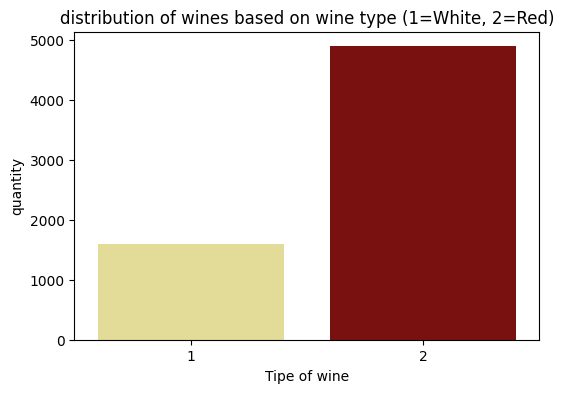

In [143]:
plt.figure(figsize=(6, 4))
sns.countplot(x='wine_type', data=dataset, palette=['#F0E68C','#8B0000'])
plt.title('distribution of wines based on wine type (1=White, 2=Red)')
plt.xlabel('Tipe of wine')
plt.ylabel('quantity')
plt.show()

### 3.2. Are there measurable chemical differences?

In [144]:
chemical_features = [
    'fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'pH',
    'sulphates',
    'alcohol',
    'sugar_acid_ratio',
    'sulfur_ratio'
]

In [145]:
chemical_dataset= dataset[chemical_features]

In [146]:
scaler = StandardScaler()
scaled_chemical_features = scaler.fit_transform(chemical_dataset)
display(pd.DataFrame(scaled_chemical_features, columns=chemical_features).head())

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,pH,sulphates,alcohol,sugar_acid_ratio,sulfur_ratio
0,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.813090,0.193097,-0.915464,-0.751268,0.294953
1,0.451036,3.282235,-2.192833,-0.597640,1.197975,-0.311320,-0.862469,-0.115073,0.999579,-0.580068,-0.641914,0.692954
2,0.451036,2.553300,-1.917553,-0.660699,1.026697,-0.874763,-1.092486,0.258120,0.797958,-0.580068,-0.696838,-0.072132
3,3.073817,-0.362438,1.661085,-0.744778,0.541412,-0.762074,-0.986324,-0.363868,0.327510,-0.580068,-0.875669,-0.027557
4,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.813090,0.193097,-0.915464,-0.751268,0.294953


In [147]:
scaled_df = pd.DataFrame(scaled_chemical_features, columns=chemical_features)
scaled_df['wine_type'] = dataset['wine_type']

means_by_type = scaled_df.groupby('wine_type')[chemical_features].mean().T
display(means_by_type)


wine_type,1,2
fixed_acidity,0.851887,-0.278107
volatile_acidity,1.142936,-0.373123
citric_acid,-0.327979,0.107072
residual_sugar,-0.610503,0.199305
chlorides,0.897284,-0.292927
free_sulfur_dioxide,-0.825466,0.269481
total_sulfur_dioxide,-1.225758,0.400161
pH,0.576038,-0.188053
sulphates,0.852724,-0.278380
alcohol,-0.057703,0.018838


/tmp/ipython-input-3546454199.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='wine_type', y='fixed_acidity', data=dataset, palette=['#F0E68C', '#8B0000'])


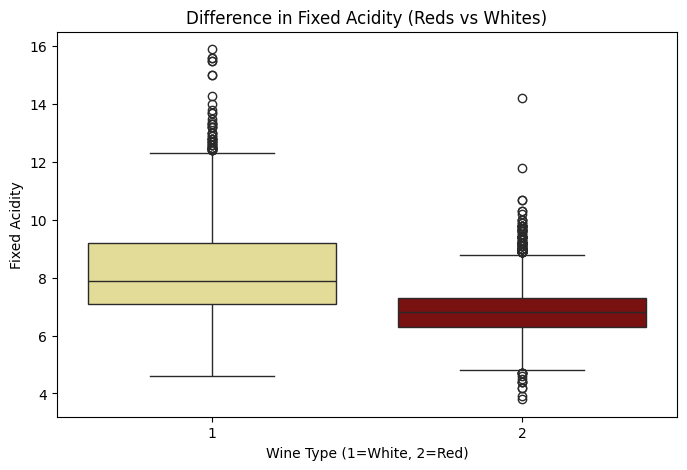

In [148]:
# We compare acidity
plt.figure(figsize=(8, 5))
sns.boxplot(x='wine_type', y='fixed_acidity', data=dataset, palette=['#F0E68C', '#8B0000'])
plt.title('Difference in Fixed Acidity (Reds vs Whites)')
plt.xlabel('Wine Type (1=White, 2=Red)')
plt.ylabel('Fixed Acidity')
plt.show()

/tmp/ipython-input-432669701.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='wine_type', y='total_sulfur_dioxide', data=dataset, palette=['#F0E68C','#8B0000'])


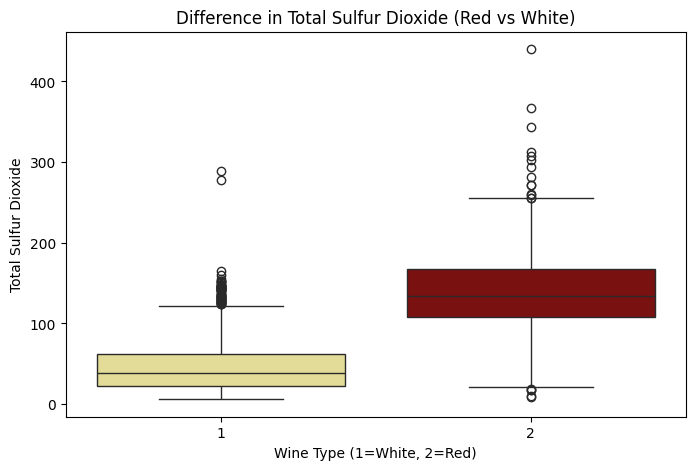

In [149]:
# We compare the sulfites
plt.figure(figsize=(8, 5))
sns.boxplot(x='wine_type', y='total_sulfur_dioxide', data=dataset, palette=['#F0E68C','#8B0000'])
plt.title('Difference in Total Sulfur Dioxide (Red vs White)')
plt.xlabel('Wine Type (1=White, 2=Red)')
plt.ylabel('Total Sulfur Dioxide')
plt.show()

### 3.3. How does the alcohol content vary between red and white wines?

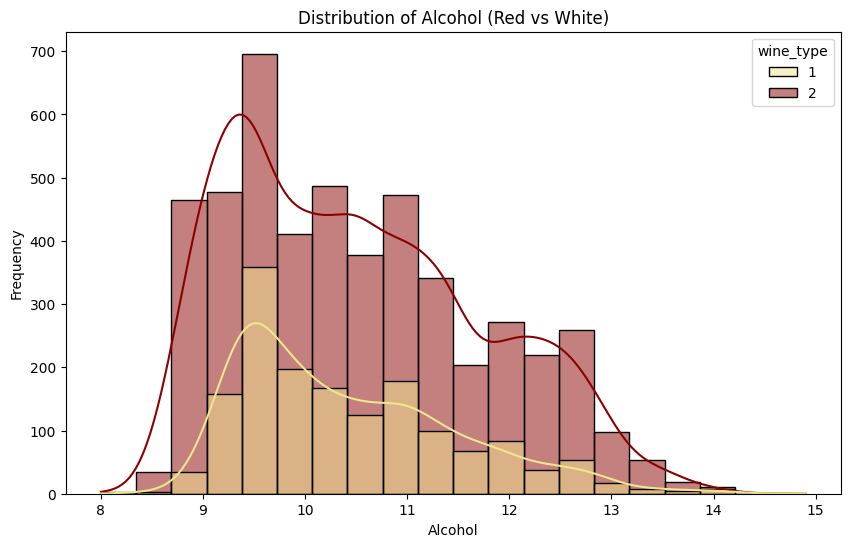

In [150]:
# Histogram of alchol type
plt.figure(figsize=(10, 6))
sns.histplot(data=dataset, x='alcohol', hue='wine_type', kde=True, bins=20, palette=[ '#F0E68C','#8B0000'])
plt.title('Distribution of Alcohol (Red vs White)')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.show()

## 4. Implementation of Models





In [151]:
X_train, X_test = stratified_split(
    dataset,
    'wine_type',
    0.85,
    3234233)

print("Tamaño del set de Train:", X_train.shape)
print("Tamaño del set de Test:", X_test.shape)

Tamaño del set de Train: (5522, 26)
Tamaño del set de Test: (975, 26)


In [152]:
print(compute_column_percentages(X_train, col_name))

wine_type
1    24.610648
2    75.389352
Name: count, dtype: float64


### 4.1. Decision Tree

In [153]:
feature_names = list(x_train.columns)
class_name = y_train.columns[0]

In [154]:
DT_Model_configs = {
    "DT Model 1 (Baseline Gini)": {
        "criterion": "gini",
        "max_depth": 10,
        "min_samples_leaf": 1,
        "splitter": "best"
    },
    "DT Model 2 (Baseline Entropy)": {
        "criterion": "entropy",
        "max_depth": 10,
        "min_samples_leaf": 1,
        "splitter": "best"
    },
    "DT Model 3 (Shallow)": {
        "criterion": "gini",
        "max_depth": 5,
        "min_samples_leaf": 1,
        "splitter": "best"
    },
    "DT Model 4 (Deep / Overfit)": {
        "criterion": "gini",
        "max_depth": None,
        "min_samples_leaf": 1,
        "splitter": "best"
    },
    "DT Model 5 (More Leaf)": {
        "criterion": "gini",
        "max_depth": 10,
        "min_samples_leaf": 5,
        "splitter": "best"
    },
    "DT Model 6 (Entropy + Deep)": {
        "criterion": "entropy",
        "max_depth": 20,
        "min_samples_leaf": 1,
        "splitter": "best"
    },
    "DT Model 7 (Random Splitter)": {
        "criterion": "gini",
        "max_depth": 10,
        "min_samples_leaf": 1,
        "splitter": "random"
    },
    "DT Model 8 (Strong Reg)": {
        "criterion": "entropy",
        "max_depth": 10,
        "min_samples_leaf": 10,
        "splitter": "best"
    }
}

In [155]:
dt_results = {}
trained_dt_models = {}

print("Iniciando entrenamiento de 8 modelos de Árbol de Decisión...")

for model_name, params in DT_Model_configs.items():
    print(f"--- Entrenando: {model_name} ---")
    model_dt = DecisionTreeClassifier(
        **params,
        random_state=12345
    )

    model_dt.fit(x_train, y_train.values.ravel())

    trained_dt_models[model_name] = model_dt

    y_pred = model_dt.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    dt_results[model_name] = accuracy

    print(f"Resultado (Accuracy) para {model_name}: {accuracy:.4f}\n")

Iniciando entrenamiento de 8 modelos de Árbol de Decisión...
--- Entrenando: DT Model 1 (Baseline Gini) ---
Resultado (Accuracy) para DT Model 1 (Baseline Gini): 0.9954

--- Entrenando: DT Model 2 (Baseline Entropy) ---
Resultado (Accuracy) para DT Model 2 (Baseline Entropy): 0.9938

--- Entrenando: DT Model 3 (Shallow) ---
Resultado (Accuracy) para DT Model 3 (Shallow): 0.9954

--- Entrenando: DT Model 4 (Deep / Overfit) ---
Resultado (Accuracy) para DT Model 4 (Deep / Overfit): 0.9954

--- Entrenando: DT Model 5 (More Leaf) ---
Resultado (Accuracy) para DT Model 5 (More Leaf): 0.9923

--- Entrenando: DT Model 6 (Entropy + Deep) ---
Resultado (Accuracy) para DT Model 6 (Entropy + Deep): 0.9938

--- Entrenando: DT Model 7 (Random Splitter) ---
Resultado (Accuracy) para DT Model 7 (Random Splitter): 1.0000

--- Entrenando: DT Model 8 (Strong Reg) ---
Resultado (Accuracy) para DT Model 8 (Strong Reg): 0.9908



Plotting DT Model 7 (Random Splitter)...


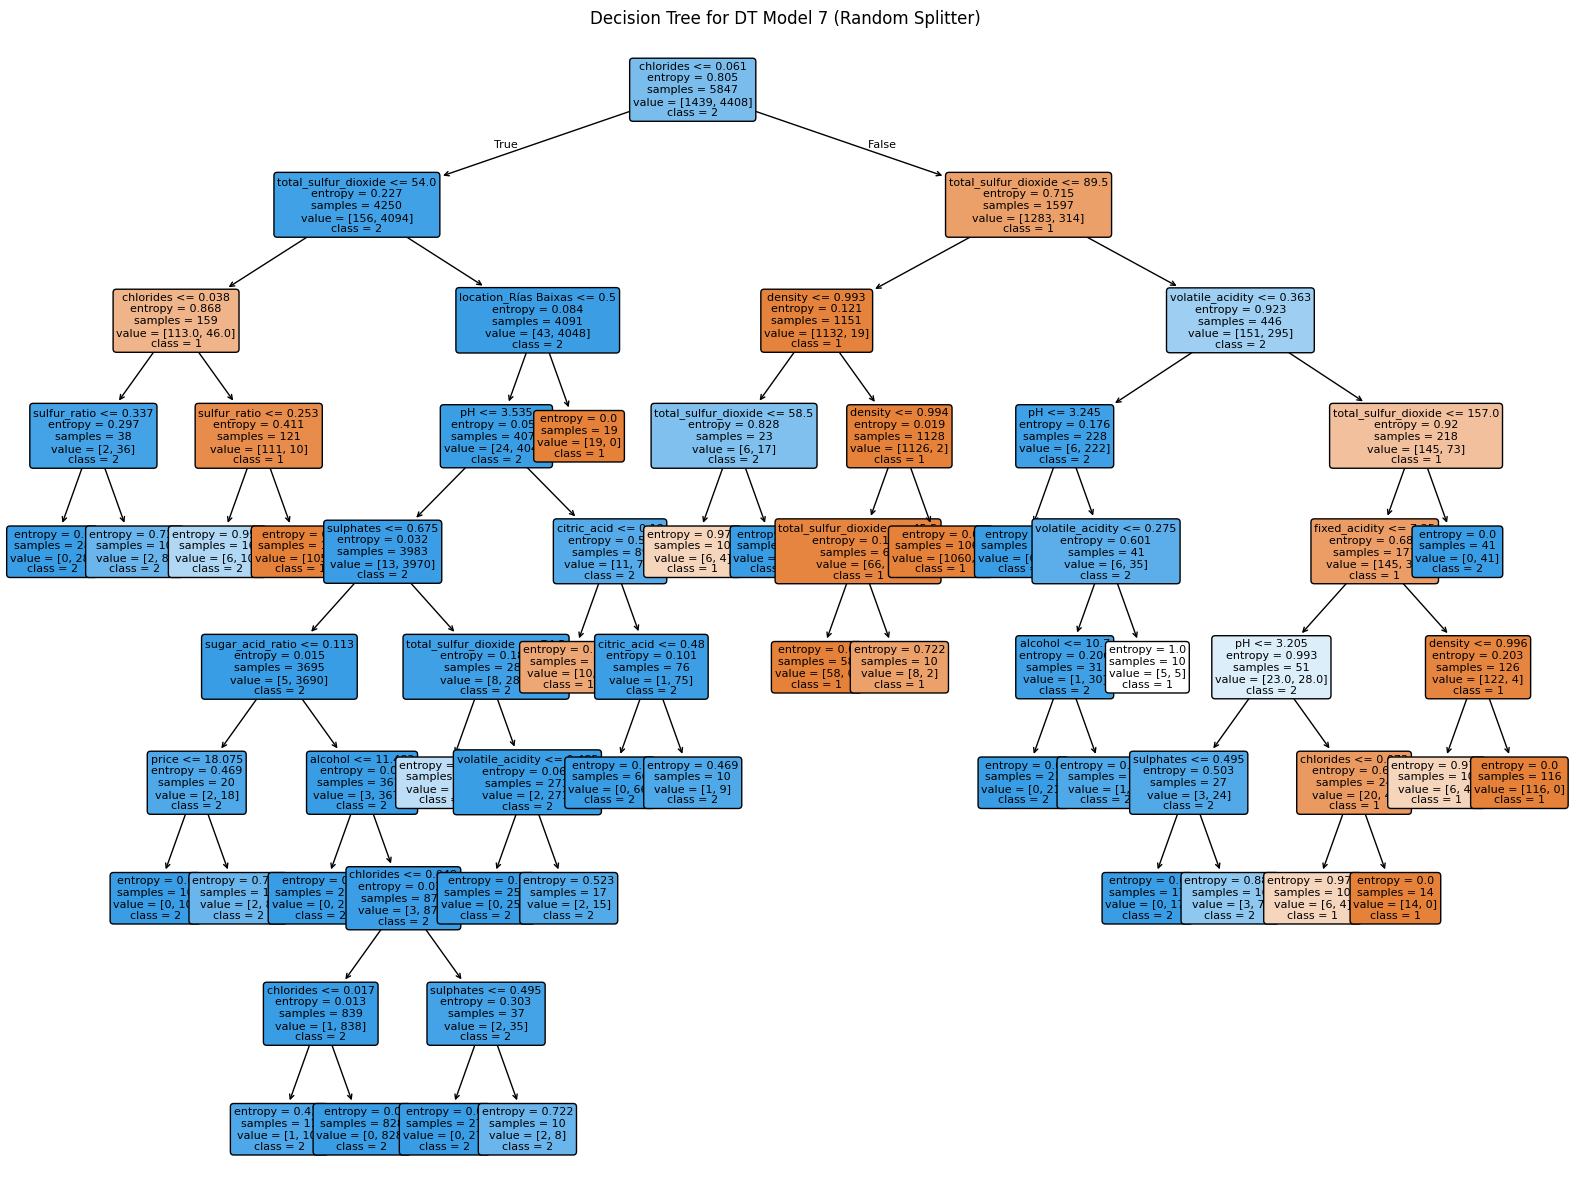

In [156]:
model_name = "DT Model 7 (Random Splitter)"
print(f"Plotting {model_name}...")
plt.figure(figsize=(20, 15))
tree.plot_tree(
    model_dt,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(y_train.iloc[:,0].unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Decision Tree for {model_name}")
plt.show()

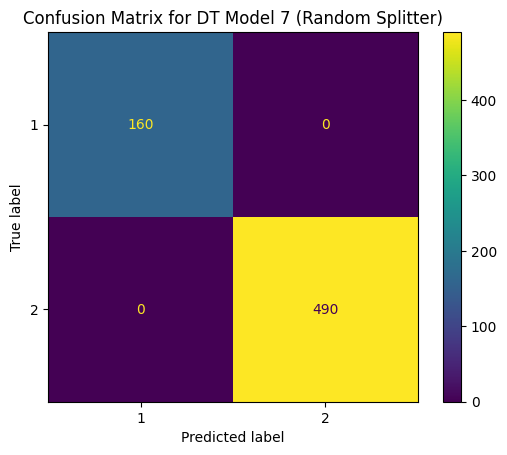

In [157]:
model_dt_7 = trained_dt_models['DT Model 7 (Random Splitter)']
y_pred_dt_7 = model_dt_7.predict(x_test)

cm_dt_7 = confusion_matrix(y_test, y_pred_dt_7)

ConfusionMatrixDisplay(cm_dt_7, display_labels=[str(c) for c in sorted(y_test['wine_type'].unique())]).plot()
plt.title('Confusion Matrix for DT Model 7 (Random Splitter)')
plt.show()

In [158]:
print(classification_report(
    y_test,
    y_pred_dt_7))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       160
           2       1.00      1.00      1.00       490

    accuracy                           1.00       650
   macro avg       1.00      1.00      1.00       650
weighted avg       1.00      1.00      1.00       650



#KNN

In [159]:
KNN_Model_configs = {
    "KNN 1 (K=3, Uniform)": {
        "n_neighbors": 3,
        "weights": "uniform",
        "metric": "minkowski", "p": 2
    },
    "KNN 2 (K=3, Distance)": {
        "n_neighbors": 3,
        "weights": "distance",
        "metric": "minkowski", "p": 2
    },
    "KNN 3 (K=5, Uniform)": {
        "n_neighbors": 5,
        "weights": "uniform",
        "metric": "minkowski", "p": 2
    },
    "KNN 4 (K=5, Distance)": {
        "n_neighbors": 5,
        "weights": "distance",
        "metric": "minkowski", "p": 2
    },
    "KNN 5 (K=11, Uniform)": {
        "n_neighbors": 11,
        "weights": "uniform",
        "metric": "minkowski", "p": 2
    },
    "KNN 6 (K=11, Distance)": {
        "n_neighbors": 11,
        "weights": "distance",
        "metric": "minkowski", "p": 2
    },
    "KNN 7 (K=5, Manhattan)": {
        "n_neighbors": 5,
        "weights": "uniform",
        "metric": "manhattan"
    },
    "KNN 8 (K=5, Manhattan, Dist)": {
        "n_neighbors": 5,
        "weights": "distance",
        "metric": "manhattan"
    },
    "KNN 9 (K=7, Uniform)": {
        "n_neighbors": 7,
        "weights": "uniform",
        "metric": "euclidean"
    },
    "KNN 10 (K=7, Distance)": {
        "n_neighbors": 7,
        "weights": "distance",
        "metric": "euclidean"
    },
    "KNN 11 (K=9, Uniform)": {
        "n_neighbors": 9,
        "weights": "uniform",
        "metric": "euclidean"
    },
    "KNN 12 (K=9, Distance)": {
        "n_neighbors": 9,
        "weights": "distance",
        "metric": "euclidean"
    },
    "KNN 13 (K=15, Uniform)": {
        "n_neighbors": 15,
        "weights": "uniform",
        "metric": "euclidean"
    },
    "KNN 14 (K=15, Distance)": {
        "n_neighbors": 15,
        "weights": "distance",
        "metric": "euclidean"
    },
    "KNN 15 (K=7, Chebyshev)": {
        "n_neighbors": 7,
        "weights": "uniform",
        "metric": "chebyshev"
    },
    "KNN 16 (K=7, Chebyshev, Dist)": {
        "n_neighbors": 7,
        "weights": "distance",
        "metric": "chebyshev"
    }
}

In [160]:
knn_results = {}
for model_name, params in KNN_Model_configs.items():
    print(f"--- Entrenando: {model_name} ---")

    model_knn = neighbors.KNeighborsClassifier(
        **params,
        n_jobs=-1
    )

    model_knn.fit(x_train, y_train.values.ravel())

    y_pred = model_knn.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    knn_results[model_name] = accuracy

    print(f"Resultado (Accuracy) para {model_name}: {accuracy:.4f}\n")

--- Entrenando: KNN 1 (K=3, Uniform) ---
Resultado (Accuracy) para KNN 1 (K=3, Uniform): 0.9369

--- Entrenando: KNN 2 (K=3, Distance) ---
Resultado (Accuracy) para KNN 2 (K=3, Distance): 0.9400

--- Entrenando: KNN 3 (K=5, Uniform) ---
Resultado (Accuracy) para KNN 3 (K=5, Uniform): 0.9508

--- Entrenando: KNN 4 (K=5, Distance) ---
Resultado (Accuracy) para KNN 4 (K=5, Distance): 0.9538

--- Entrenando: KNN 5 (K=11, Uniform) ---
Resultado (Accuracy) para KNN 5 (K=11, Uniform): 0.9462

--- Entrenando: KNN 6 (K=11, Distance) ---
Resultado (Accuracy) para KNN 6 (K=11, Distance): 0.9462

--- Entrenando: KNN 7 (K=5, Manhattan) ---
Resultado (Accuracy) para KNN 7 (K=5, Manhattan): 0.9692

--- Entrenando: KNN 8 (K=5, Manhattan, Dist) ---
Resultado (Accuracy) para KNN 8 (K=5, Manhattan, Dist): 0.9754

--- Entrenando: KNN 9 (K=7, Uniform) ---
Resultado (Accuracy) para KNN 9 (K=7, Uniform): 0.9477

--- Entrenando: KNN 10 (K=7, Distance) ---
Resultado (Accuracy) para KNN 10 (K=7, Distance): 0.94

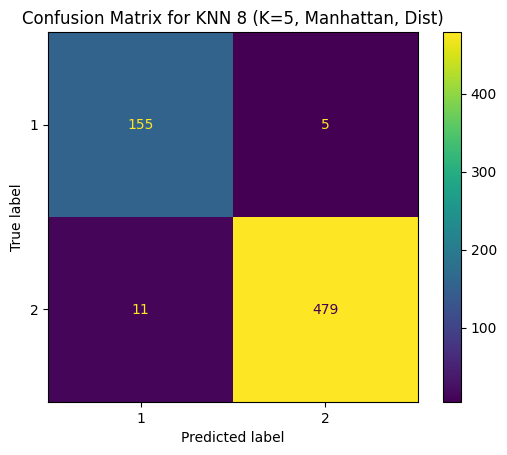

In [161]:
# Get the configuration for KNN 8
config_knn_8 = KNN_Model_configs["KNN 8 (K=5, Manhattan, Dist)"]

# Instantiate and train KNN 8
model_knn_8 = neighbors.KNeighborsClassifier(
    **config_knn_8,
    n_jobs=-1
)
model_knn_8.fit(x_train, y_train.values.ravel())

# Make predictions with KNN 8
y_pred_knn_8 = model_knn_8.predict(x_test)

# Plot the confusion matrix for KNN 8
cm_knn_8 = confusion_matrix(y_test, y_pred_knn_8)
ConfusionMatrixDisplay(cm_knn_8, display_labels=[str(c) for c in sorted(y_test['wine_type'].unique())]).plot()
plt.title('Confusion Matrix for KNN 8 (K=5, Manhattan, Dist)')
plt.show()

In [162]:
print(classification_report(
    y_test,
    y_pred_knn_8))

              precision    recall  f1-score   support

           1       0.93      0.97      0.95       160
           2       0.99      0.98      0.98       490

    accuracy                           0.98       650
   macro avg       0.96      0.97      0.97       650
weighted avg       0.98      0.98      0.98       650



Naive Bayes

In [163]:
model_nb = GaussianNB()
model_nb.fit(
    x_train,
    y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

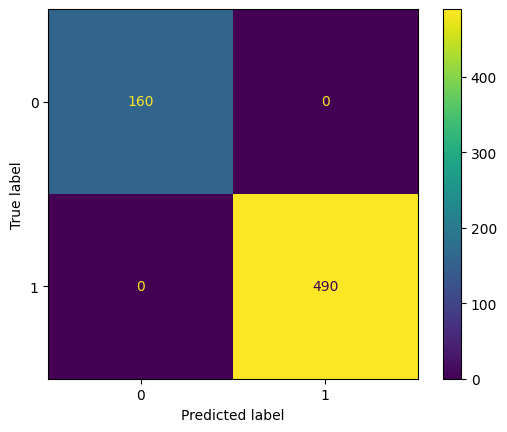

In [164]:
y_pred_nb = model_nb.predict(x_test)

cm = confusion_matrix(y_test, y_pred_nb)

ConfusionMatrixDisplay(cm).plot()

In [165]:
print(classification_report(
    y_test,
    y_pred_nb))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       160
           2       1.00      1.00      1.00       490

    accuracy                           1.00       650
   macro avg       1.00      1.00      1.00       650
weighted avg       1.00      1.00      1.00       650



SVM

In [166]:
SVM_Model_configs = {
    "SVM 1 (LinearSVC C=1)": {
        "class": svm.LinearSVC,
        "params": {"C": 1.0, "loss": "squared_hinge", "max_iter": 2000}
    },
    "SVM 2 (LinearSVC C=10)": {
        "class": svm.LinearSVC,
        "params": {"C": 10.0, "loss": "squared_hinge", "max_iter": 2000}
    },
    "SVM 3 (LinearSVC C=0.1)": {
        "class": svm.LinearSVC,
        "params": {"C": 0.1, "loss": "squared_hinge", "max_iter": 2000}
    },
    "SVM 4 (SVC Linear)": {
        "class": svm.SVC,
        "params": {"kernel": "linear", "C": 1.0}
    },
    "SVM 5 (SVC RBF - Default)": {
        "class": svm.SVC,
        "params": {"kernel": "rbf", "C": 1.0, "gamma": "scale"}
    },
    "SVM 6 (SVC RBF - High C)": {
        "class": svm.SVC,
        "params": {"kernel": "rbf", "C": 100.0, "gamma": "scale"}
    },
    "SVM 7 (SVC Poly d=3)": {
        "class": svm.SVC,
        "params": {"kernel": "poly", "C": 1.0, "degree": 3}
    },
    "SVM 8 (SVC Poly d=2)": {
        "class": svm.SVC,
        "params": {"kernel": "poly", "C": 1.0, "degree": 2}
    },
    "SVM 9 (SVC Poly d=4)": {
        "class": svm.SVC,
        "params": {"kernel": "poly", "C": 1.0, "degree": 4}
    },
    "SVM 10 (SVC Sigmoid)": {
        "class": svm.SVC,
        "params": {"kernel": "sigmoid", "C": 1.0, "gamma": "scale"}
    },
    "SVM 11 (SVC RBF - Low Gamma)": {
        "class": svm.SVC,
        "params": {"kernel": "rbf", "C": 1.0, "gamma": 0.1}
    },
    "SVM 12 (SVC RBF - High Gamma)": {
        "class": svm.SVC,
        "params": {"kernel": "rbf", "C": 1.0, "gamma": 1.0}
    },
    "SVM 13 (LinearSVC C=0.01)": {
        "class": svm.LinearSVC,
        "params": {"C": 0.01, "loss": "squared_hinge", "max_iter": 2000}
    },
    "SVM 14 (SVC Linear - High C)": {
        "class": svm.SVC,
        "params": {"kernel": "linear", "C": 10.0}
    },
    "SVM 15 (SVC RBF - Low C)": {
        "class": svm.SVC,
        "params": {"kernel": "rbf", "C": 0.1, "gamma": "scale"}
    },
    "SVM 16 (SVC Poly d=3, High C)": {
        "class": svm.SVC,
        "params": {"kernel": "poly", "C": 10.0, "degree": 3}
    }
}

In [167]:
svm_results = {}
print("\nIniciando entrenamiento de 7 modelos SVM...")
for model_name, config in SVM_Model_configs.items():
    print(f"--- Entrenando: {model_name} ---")

    ModelClass = config["class"]
    model_params = config["params"]

    model_svm = ModelClass(
        **model_params,
        random_state=12345
    )

    model_svm.fit(x_train, y_train.values.ravel())

    y_pred = model_svm.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    svm_results[model_name] = accuracy
    print(f"Resultado (Accuracy) para {model_name}: {accuracy:.4f}\n")


Iniciando entrenamiento de 7 modelos SVM...
--- Entrenando: SVM 1 (LinearSVC C=1) ---
Resultado (Accuracy) para SVM 1 (LinearSVC C=1): 1.0000

--- Entrenando: SVM 2 (LinearSVC C=10) ---
Resultado (Accuracy) para SVM 2 (LinearSVC C=10): 1.0000

--- Entrenando: SVM 3 (LinearSVC C=0.1) ---
Resultado (Accuracy) para SVM 3 (LinearSVC C=0.1): 1.0000

--- Entrenando: SVM 4 (SVC Linear) ---
Resultado (Accuracy) para SVM 4 (SVC Linear): 1.0000

--- Entrenando: SVM 5 (SVC RBF - Default) ---
Resultado (Accuracy) para SVM 5 (SVC RBF - Default): 0.9385

--- Entrenando: SVM 6 (SVC RBF - High C) ---
Resultado (Accuracy) para SVM 6 (SVC RBF - High C): 1.0000

--- Entrenando: SVM 7 (SVC Poly d=3) ---
Resultado (Accuracy) para SVM 7 (SVC Poly d=3): 0.9277

--- Entrenando: SVM 8 (SVC Poly d=2) ---
Resultado (Accuracy) para SVM 8 (SVC Poly d=2): 0.9277

--- Entrenando: SVM 9 (SVC Poly d=4) ---
Resultado (Accuracy) para SVM 9 (SVC Poly d=4): 0.9200

--- Entrenando: SVM 10 (SVC Sigmoid) ---
Resultado (Accu

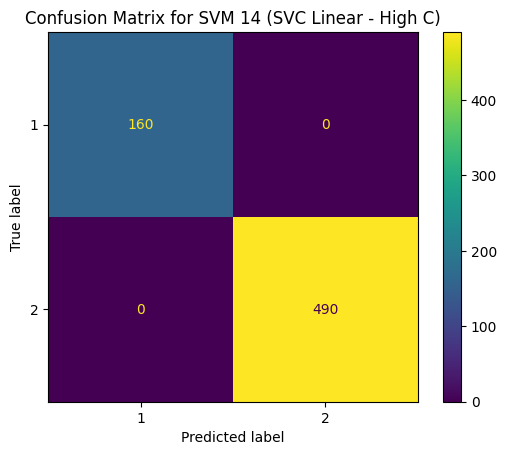

In [168]:
# Get the configuration for SVM 14
config_svm_14 = SVM_Model_configs["SVM 14 (SVC Linear - High C)"]
ModelClass_14 = config_svm_14["class"]
model_params_14 = config_svm_14["params"]

# Instantiate and train SVM 4
model_svm_14 = ModelClass_14(**model_params_14, random_state=12345)
model_svm_14.fit(x_train, y_train.values.ravel())

# Make predictions with SVM 4
y_pred_svm_14 = model_svm_14.predict(x_test)

# Plot the confusion matrix for SVM 4
cm_svm_14 = confusion_matrix(y_test, y_pred_svm_14)
ConfusionMatrixDisplay(cm_svm_14, display_labels=[str(c) for c in sorted(y_test['wine_type'].unique())]).plot()
plt.title('Confusion Matrix for SVM 14 (SVC Linear - High C)')
plt.show()

In [169]:
print(classification_report(
    y_test,
    y_pred_svm_14))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       160
           2       1.00      1.00      1.00       490

    accuracy                           1.00       650
   macro avg       1.00      1.00      1.00       650
weighted avg       1.00      1.00      1.00       650



#Random Forest

In [170]:
model_configs = {
    "Model 1 (Baseline)": {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_leaf": 1,
        "criterion": "gini"
    },
    "Model 2 (Shallow)": {
        "n_estimators": 100,
        "max_depth": 5,
        "min_samples_leaf": 1,
        "criterion": "gini"
    },
    "Model 3 (Many Shallow)": {
        "n_estimators": 300,
        "max_depth": 5,
        "min_samples_leaf": 1,
        "criterion": "gini"
    },
    "Model 4 (Entropy)": {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Model 5 (More Leaf)": {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_leaf": 5,
        "criterion": "gini"
    },
    "Model 6 (Big & Deep)": {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "criterion": "gini"
    },
    "Model 7 (Extra model 1)": {
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Model 8 (Extra model 2)": {
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_leaf": 5,
        "criterion": "entropy"
    },

    "Model 9 (Full Depth)": {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "criterion": "gini"
    },
    "Model 10 (Full Depth + Leaf 5)": {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 5,
        "criterion": "gini"
    },
    "Model 11 (Full Depth + Entropy)": {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Model 12 (Strong Leaf Reg)": {
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 10,
        "criterion": "gini"
    },
    "Model 13 (Many Trees)": {
        "n_estimators": 500,
        "max_depth": 10,
        "min_samples_leaf": 1,
        "criterion": "gini"
    },
    "Model 14 (Max Complexity)": {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Model 15 (Weak/Fast)": {
        "n_estimators": 50,
        "max_depth": 5,
        "min_samples_leaf": 5,
        "criterion": "gini"
    },
    "Model 16 (Full Depth + Leaf 10)": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 10,
        "criterion": "entropy"
    }
}

In [171]:
model_results = {}
print("Iniciando entrenamiento de 8 modelos...")
for model_name, params in model_configs.items():
    print(f"--- Entrenando: {model_name} ---")

    model_rf = RandomForestClassifier(
            **params,
            random_state=2322
        )
    model_rf.fit(x_train, y_train)
    y_pred_rf = model_rf.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred_rf)
    model_results[model_name] = accuracy

    print(f"Resultado (Accuracy) para {model_name}: {accuracy:.4f}\n")

Iniciando entrenamiento de 8 modelos...
--- Entrenando: Model 1 (Baseline) ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Resultado (Accuracy) para Model 1 (Baseline): 1.0000

--- Entrenando: Model 2 (Shallow) ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Resultado (Accuracy) para Model 2 (Shallow): 1.0000

--- Entrenando: Model 3 (Many Shallow) ---


...

Resultado (Accuracy) para Model 14 (Max Complexity): 1.0000

--- Entrenando: Model 15 (Weak/Fast) ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Resultado (Accuracy) para Model 15 (Weak/Fast): 0.9985

--- Entrenando: Model 16 (Full Depth + Leaf 10) ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Resultado (Accuracy) para Model 16 (Full Depth + Leaf 10): 0.9985



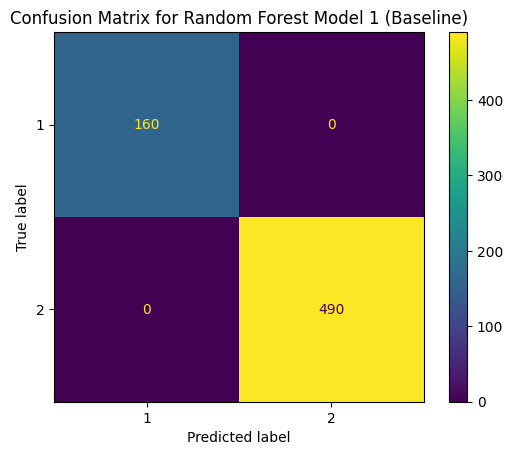

In [172]:
# Get the configuration for Model 1 (Baseline)
config_rf_1 = model_configs["Model 1 (Baseline)"]

# Instantiate and train Model 1 (Baseline)
model_rf_1 = RandomForestClassifier(
    **config_rf_1,
    random_state=2322
)
model_rf_1.fit(x_train, y_train.values.ravel())

# Make predictions with Model 1 (Baseline)
y_pred_rf_1 = model_rf_1.predict(x_test)

# Plot the confusion matrix for Model 1 (Baseline)
cm_rf_1 = confusion_matrix(y_test, y_pred_rf_1)
ConfusionMatrixDisplay(cm_rf_1, display_labels=[str(c) for c in sorted(y_test['wine_type'].unique())]).plot()
plt.title('Confusion Matrix for Random Forest Model 1 (Baseline)')
plt.show()

In [173]:
print(classification_report(
    y_test,
    y_pred_rf_1))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       160
           2       1.00      1.00      1.00       490

    accuracy                           1.00       650
   macro avg       1.00      1.00      1.00       650
weighted avg       1.00      1.00      1.00       650



#3. EVALUATION

For the best **Decision Tree** model we got this confusion matrix:

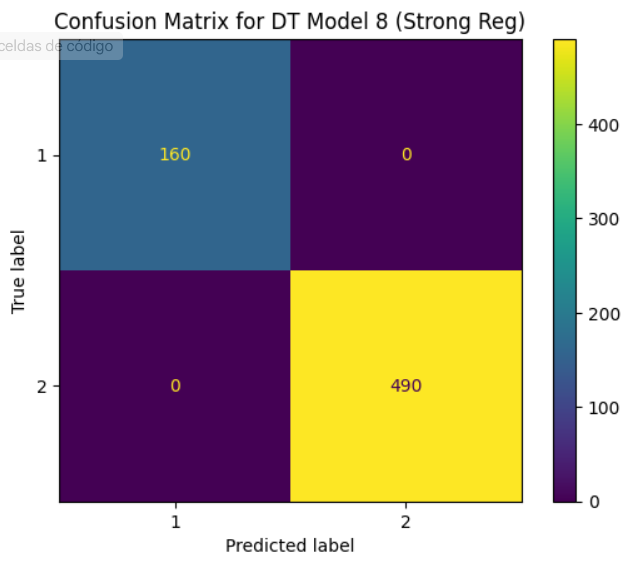

The Decision Tree performed greatly in this exercise, acheiving a perfect prediction for the test sub-dataset.

False Negatives (FN) = 0

False Positives (FP) = 0

For the best **KNN** model we got this confusion matrix
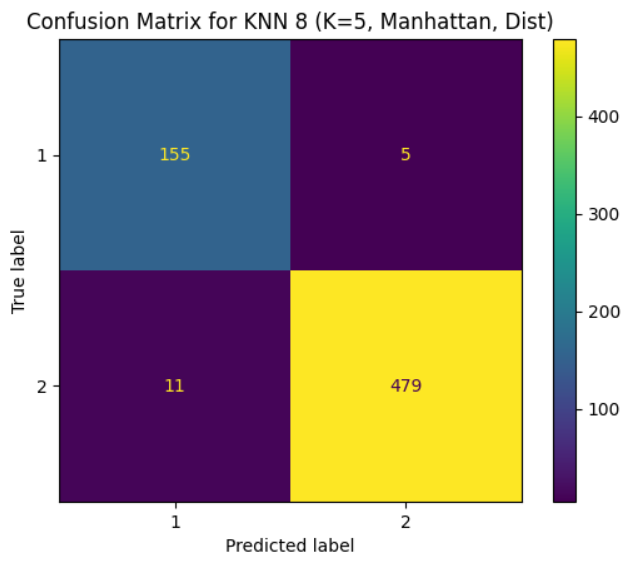

The KNN performed poorly compared to the other models in this exercise, having misspredicted 16 instances in the whole dataset. This are nonetheless, great results for the model, as it classified correctly 155 instances of white wine and 479 instances of red wine.

In this binary confusion matrix the 1s will be positive and 2s will be negative, this is just to explain more easily the matrix.

False negatives (FN) = 11

False positives (FP) = 5

For the best **Naive Bayes** model we got this confusion matrix:

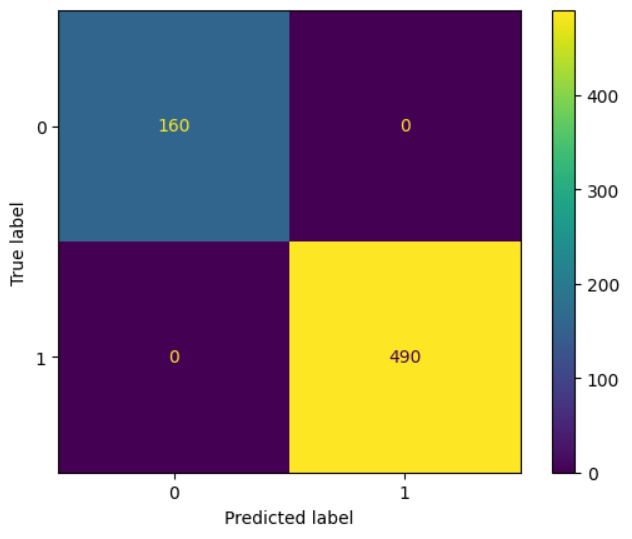

The Naive Bayes performed as good as the majority of the models this time, as this time achived the perfect score acomplished by 3 other models.

False Negatives (FN) = 0

False Positives (FP) = 0

For the best **SVM** model we got this confusion matrix:

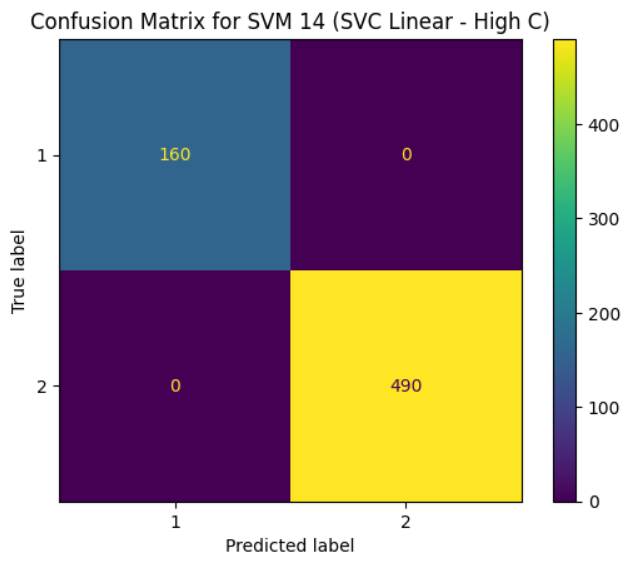

The SVM performed greatly in this exercise, acheiving a perfect prediction for the test sub-dataset.

False Negatives (FN) = 0

False Positives (FP) = 0

For the best **Random Forest** model we got this confusion matrix:

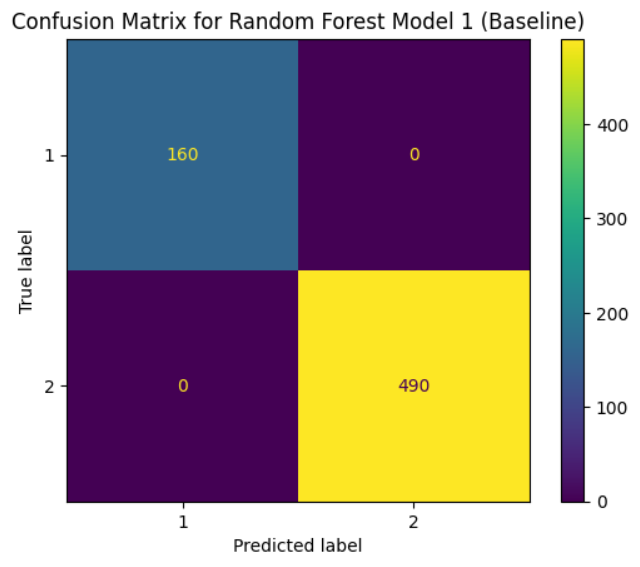

The Random Forest performed greatly in this exercise, acheiving a perfect prediction for the test sub-dataset.

False Negavitves (FN) = 0

False Positives (FP) = 0

In [174]:
# As we made before, we are going to print the correlations but this time we are going to print them all
quality_correlations = dataset.corr(numeric_only=True)['wine_type'].drop('wine_type')
sorted_correlations = quality_correlations.abs().sort_values(ascending=False)

print("Correlated Features with wine_type:\n")
print(quality_correlations[sorted_correlations.index])

Correlated Features with wine_type:

total_sulfur_dioxide         0.700357
volatile_acidity            -0.653036
location_Rías Baixas        -0.566435
chlorides                   -0.512678
location_Rueda              -0.495995
sulphates                   -0.487218
fixed_acidity               -0.486740
free_sulfur_dioxide          0.471644
region_class                 0.452021
sulfur_ratio                -0.438000
density                     -0.390645
location_Penedès            -0.384410
sugar_acid_ratio             0.382514
residual_sugar               0.348821
location_Rioja               0.347459
pH                          -0.329129
location_Valdeorras         -0.312717
location_Ribera del Duero    0.270560
location_Priorat             0.205940
location_Toro                0.197273
citric_acid                  0.187397
location_Bierzo              0.167647
quality                      0.119323
price                        0.117321
alcohol                      0.032970
Name: wine_ty

In [175]:
physicochemical_features = [
    'fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'sugar_acid_ratio',
    'sulfur_ratio'
]

physicochemical_dataset= dataset[physicochemical_features]

In [176]:
scaler = StandardScaler()
scaled_physicochemical_features = scaler.fit_transform(physicochemical_dataset)
display(pd.DataFrame(scaled_physicochemical_features, columns=physicochemical_features).head())

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,sugar_acid_ratio,sulfur_ratio
0,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464,-0.751268,0.294953
1,0.451036,3.282235,-2.192833,-0.597640,1.197975,-0.311320,-0.862469,0.701486,-0.115073,0.999579,-0.580068,-0.641914,0.692954
2,0.451036,2.553300,-1.917553,-0.660699,1.026697,-0.874763,-1.092486,0.768188,0.258120,0.797958,-0.580068,-0.696838,-0.072132
3,3.073817,-0.362438,1.661085,-0.744778,0.541412,-0.762074,-0.986324,1.101694,-0.363868,0.327510,-0.580068,-0.875669,-0.027557
4,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464,-0.751268,0.294953


In [177]:
# Create a DataFrame for scaled physicochemical features including wine_type
scaled_physicochemical_features_df = pd.DataFrame(scaled_physicochemical_features, columns=physicochemical_features)
scaled_physicochemical_features_df['wine_type'] = dataset['wine_type']

physicochemical_prototypes = scaled_physicochemical_features_df.groupby('wine_type')[physicochemical_features].mean()

# Average physicochemical components
avg_blanco_physicochemical = physicochemical_prototypes.loc[1]
avg_tinto_physicochemical = physicochemical_prototypes.loc[2]

physicochemical_prototypes.head()
avg_tinto_physicochemical.head()

,2
fixed_acidity,-0.278107
volatile_acidity,-0.373123
citric_acid,0.107072
residual_sugar,0.199305
chlorides,-0.292927


In [178]:
def dist(row, centroide):
    return np.linalg.norm(row - centroide)

scaled_physicochemical_features_df['dist_to_blanco'] = scaled_physicochemical_features_df[physicochemical_features].apply(
    lambda r: dist(r, avg_blanco_physicochemical), axis=1
)

scaled_physicochemical_features_df['dist_to_tinto'] = scaled_physicochemical_features_df[physicochemical_features].apply(
    lambda r: dist(r, avg_tinto_physicochemical), axis=1
)

dataset['dist_to_blanco'] = scaled_physicochemical_features_df['dist_to_blanco']
dataset['dist_to_tinto']  = scaled_physicochemical_features_df['dist_to_tinto']


In [179]:
labels = ['Low', 'Medium', 'High']

for dist_col, cat_col in [
    ('dist_to_blanco', 'Distance_Category_White'),
    ('dist_to_tinto',  'Distance_Category_Red')
]:
    dataset[cat_col] = pd.qcut(
        dataset[dist_col],
        q=3,
        labels=labels,
        duplicates='drop'
    )

dataset['diff_dist'] = dataset['dist_to_blanco'] - dataset['dist_to_tinto']
dataset['abs_diff']  = dataset['diff_dist'].abs()

intermediate_threshold = dataset['abs_diff'].quantile(0.10)
print("Intermediate threshold (abs diff):", intermediate_threshold)

conditions = [
    dataset['abs_diff'] <= intermediate_threshold,   # similar to both
    dataset['diff_dist'] > 0,                        # closer to red
    dataset['diff_dist'] <= 0                        # closer to white
]

choices = ['Intermediate', 'Clearly Red', 'Clearly White']

dataset['Wine_Classification'] = np.select(conditions, choices, default='Unknown')

print("\nDistribution of wines by the new classification:")
print(dataset['Wine_Classification'].value_counts())

Intermediate threshold (abs diff): 0.9506132861237393

Distribution of wines by the new classification:
Wine_Classification
Clearly Red      4435
Clearly White    1412
Intermediate      650
Name: count, dtype: int64


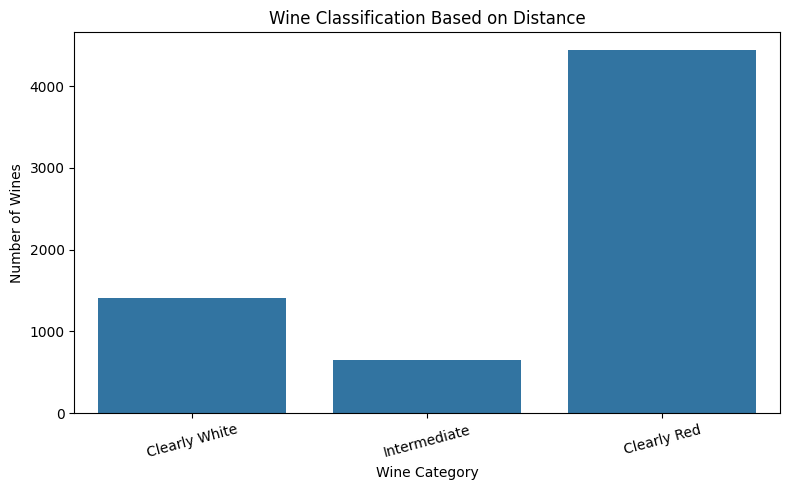

In [180]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Wine_Classification', data=dataset)
plt.title('Wine Classification Based on Distance')
plt.xlabel('Wine Category')
plt.ylabel('Number of Wines')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [186]:
scaled_pca_df = scaled_physicochemical_features_df.copy()

In [182]:
scaled_pca_df.loc[dataset['Wine_Classification'] == 'Intermediate', 'wine_type'] = 3

In [183]:
principalComponents = pca.fit_transform(scaled_pca_df[physicochemical_features])

principalDf = pd.DataFrame(
    data = principalComponents,
    columns = ['principal component 1', 'principal component 2'],
    index = scaled_pca_df.index
)

In [184]:
principalDf['wine_type'] = scaled_pca_df['wine_type']

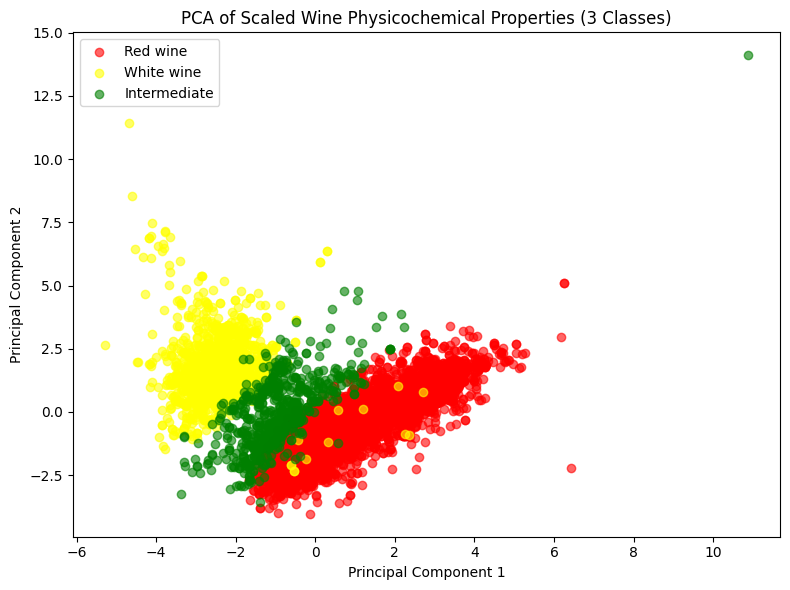

In [185]:
plt.figure(figsize=(8, 6))

groups = [
    (2, 'red',    'Red wine'),
    (1, 'yellow', 'White wine'),
    (3, 'green',  'Intermediate'),
]

for wine_code, color, label in groups:
    mask = principalDf['wine_type'] == wine_code
    plt.scatter(
        principalDf.loc[mask, 'principal component 1'],
        principalDf.loc[mask, 'principal component 2'],
        c=color,
        label=label,
        alpha=0.6
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Scaled Wine Physicochemical Properties (3 Classes)')
plt.legend()
plt.tight_layout()
plt.show()